Loading original data...
Loading RNN data...
Loading TGAN data...
Original data shape: (128, 6)
RNN data shape: (128, 6)
TGAN data shape: (128, 6)


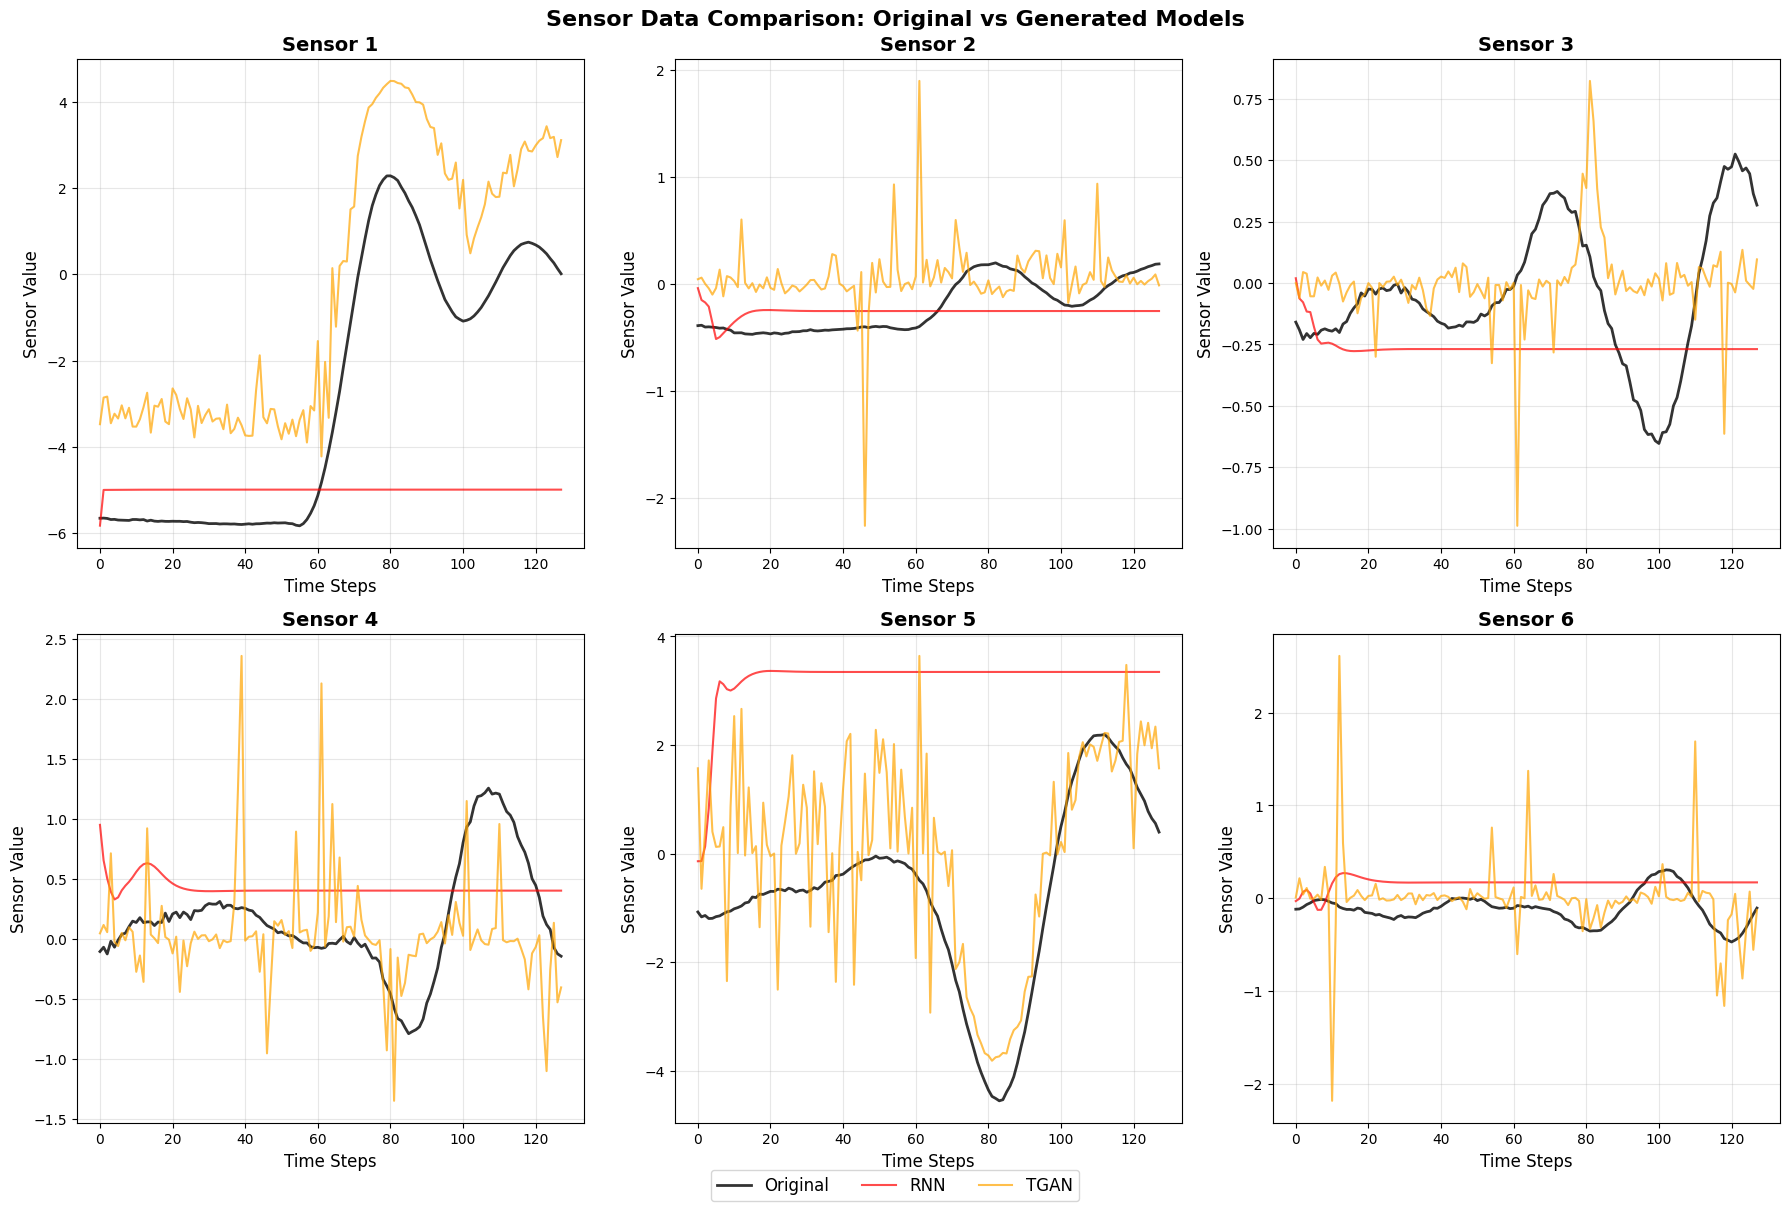


SUMMARY STATISTICS

Sensor 1:
  Original - Mean: -2.7438, Std: 3.0695
  RNN      - Mean: -4.9986, Std: 0.0735
  TGAN     - Mean: -0.2879, Std: 3.1172

Sensor 2:
  Original - Mean: -0.2109, Std: 0.2403
  RNN      - Mean: -0.2594, Std: 0.0493
  TGAN     - Mean: 0.0595, Std: 0.3187

Sensor 3:
  Original - Mean: -0.0520, Std: 0.2784
  RNN      - Mean: -0.2602, Std: 0.0405
  TGAN     - Mean: 0.0019, Std: 0.1695

Sensor 4:
  Original - Mean: 0.1585, Std: 0.4566
  RNN      - Mean: 0.4255, Std: 0.0721
  TGAN     - Mean: 0.0386, Std: 0.4485

Sensor 5:
  Original - Mean: -0.7354, Std: 1.6998
  RNN      - Mean: 3.2165, Std: 0.5706
  TGAN     - Mean: 0.0798, Std: 1.8676

Sensor 6:
  Original - Mean: -0.1126, Std: 0.1659
  RNN      - Mean: 0.1623, Std: 0.0580
  TGAN     - Mean: -0.0080, Std: 0.4246

Plot generated successfully!
Each subplot represents one sensor with 6 lines:
- Black: Original data
- Red: RNN generated
- Green: GAN generated
- Blue: DANN generated
- Magenta: CGAN generated
- Orang

In [ ]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Define file paths
original_data_path = '../../data/train.pickle'
model_data_paths = {
    'RNN': '../../data/generated_data/rnn_generated_data.pickle',
    #'GAN': '../../data/generated_data/gan_generated_data.pickle',
    #'DANN': '../../data/generated_data/dann_generated_data.pickle',
    #'CGAN': '../../data/generated_data/cgan_generated_data.pickle',
    'TGAN': '../../data/generated_data/tgan_generated_data.pickle'
}

# Define colors for each model (consistent across all plots)
colors = {
    'Original': '#000000',  # Black
    'RNN': '#FF0000',       # Red
    'GAN': '#00FF00',       # Green
    'DANN': '#0000FF',      # Blue
    'CGAN': '#FF00FF',      # Magenta
    'TGAN': '#FFA500'       # Orange
}

def load_data_and_get_sample(file_path):
    """
    Load data from pickle file and return a random sample with label 0
    """
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    
    df = pd.DataFrame(data)
    
    # Filter data with label 0
    label_0_data = df[df['label'] == 0]
    
    if len(label_0_data) == 0:
        raise ValueError(f"No data with label 0 found in {file_path}")
    
    # Randomly select one sample
    sample = label_0_data.sample(n=1).iloc[0]
    
    # Extract sensor_data (should be 128x6)
    sensor_data = np.array(sample['sensor_data'])
    
    return sensor_data

# Load original data
print("Loading original data...")
original_data = load_data_and_get_sample(original_data_path)

# Load model-generated data
model_data = {}
for model_name, file_path in model_data_paths.items():
    print(f"Loading {model_name} data...")
    model_data[model_name] = load_data_and_get_sample(file_path)

# Verify data shape
print(f"Original data shape: {original_data.shape}")
for model_name, data in model_data.items():
    print(f"{model_name} data shape: {data.shape}")

# Create plots for each sensor
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Sensor Data Comparison: Original vs Generated Models', fontsize=16, fontweight='bold')

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Time steps (128 timestamps)
time_steps = range(128)

# Plot each sensor
for sensor_idx in range(6):
    ax = axes_flat[sensor_idx]
    
    # Plot original data
    ax.plot(time_steps, original_data[:, sensor_idx], 
            color=colors['Original'], linewidth=2, label='Original', alpha=0.8)
    
    # Plot model-generated data
    for model_name, data in model_data.items():
        ax.plot(time_steps, data[:, sensor_idx], 
                color=colors[model_name], linewidth=1.5, label=model_name, alpha=0.7)
    
    # Customize plot
    ax.set_title(f'Sensor {sensor_idx + 1}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time Steps', fontsize=12)
    ax.set_ylabel('Sensor Value', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=10)
    
    # Set consistent y-axis limits for better comparison
    all_data = [original_data[:, sensor_idx]]
    for data in model_data.values():
        all_data.append(data[:, sensor_idx])
    
    y_min = min([np.min(data) for data in all_data])
    y_max = max([np.max(data) for data in all_data])
    margin = (y_max - y_min) * 0.05
    ax.set_ylim(y_min - margin, y_max + margin)

# Adjust layout to prevent overlap
plt.tight_layout()

# Add a global legend
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), 
           ncol=len(labels), fontsize=12)

# Remove individual legends to avoid clutter
for ax in axes_flat:
    ax.legend().set_visible(False)

# Save high-resolution image
plt.savefig('../../results/sensor_comparison.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)

for sensor_idx in range(6):
    print(f"\nSensor {sensor_idx + 1}:")
    print(f"  Original - Mean: {np.mean(original_data[:, sensor_idx]):.4f}, "
          f"Std: {np.std(original_data[:, sensor_idx]):.4f}")
    
    for model_name, data in model_data.items():
        print(f"  {model_name:8} - Mean: {np.mean(data[:, sensor_idx]):.4f}, "
              f"Std: {np.std(data[:, sensor_idx]):.4f}")